In [1]:
from PIL import Image, ImageDraw, ImageFont, ImageOps
import string
from matplotlib import pyplot as plt


In [2]:
asciis = list(filter(lambda a: a.isprintable(), string.printable))
asciis = "".join(asciis)

asciis

'0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~ '

In [3]:
fnt = ImageFont.truetype("../fonts/CascadiaMono.ttf", 11)
bbox = fnt.getbbox(asciis)
width, height = bbox[2], bbox[3]
letter_width = width / len(asciis)

print(bbox)
print(width, height)
print(letter_width)
print(height / letter_width)

(0, 1, 570, 14)
570 14
6.0
2.3333333333333335


In [4]:
img = Image.new(mode="L", size=(width, height), color=(0))
img_d = ImageDraw.Draw(img)

img_d.text((0,0), asciis, font=fnt, fill=(255))

img

(285, 7)
3.0


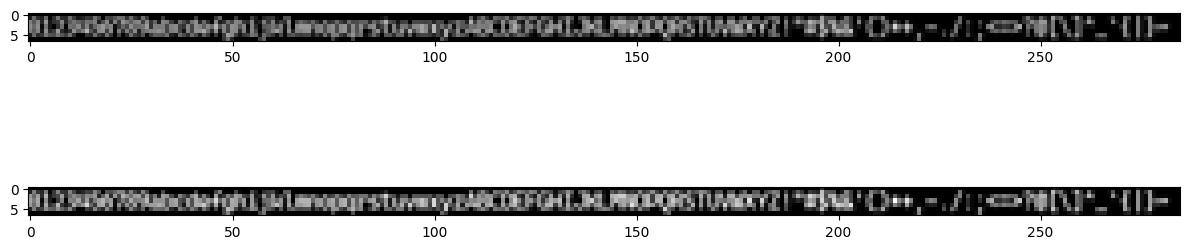

In [5]:
w_scale, h_scale = 0.5, 0.5
resized_box = (int(img.width * w_scale), int(img.height * h_scale))
print(resized_box)
print(resized_box[0] / len(asciis))
resized_img = img.resize(resized_box)
fig, axs = plt.subplots(nrows=2, figsize=(12, 8), layout='tight')
axs[0].imshow(resized_img, interpolation='nearest', cmap='gray', vmin=0, vmax=255)
axs[1].imshow(ImageOps.autocontrast(resized_img), interpolation='nearest', cmap='gray', vmin=0, vmax=255)

(95, 1)


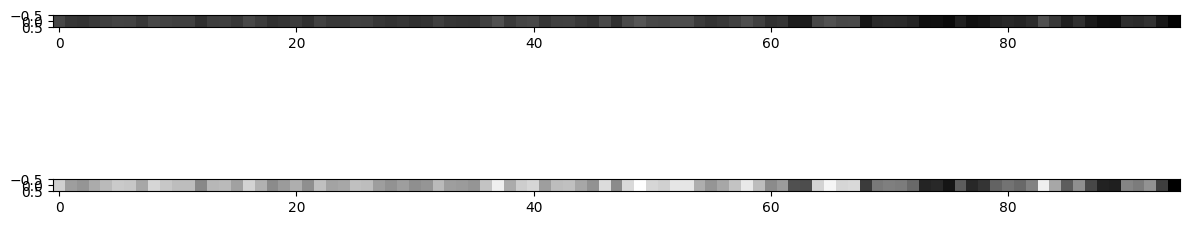

In [6]:
w_scale, h_scale = 1/letter_width, 1/height
resized_box = (int(img.width * w_scale), int(img.height * h_scale))
print(resized_box)
resized_img = img.resize(resized_box)
fig, axs = plt.subplots(nrows=2, figsize=(12, 8), layout='tight')
axs[0].imshow(resized_img, interpolation='nearest', cmap='gray', vmin=0, vmax=255)
axs[1].imshow(ImageOps.autocontrast(resized_img), interpolation='nearest', cmap='gray', vmin=0, vmax=255)

(95, 2)


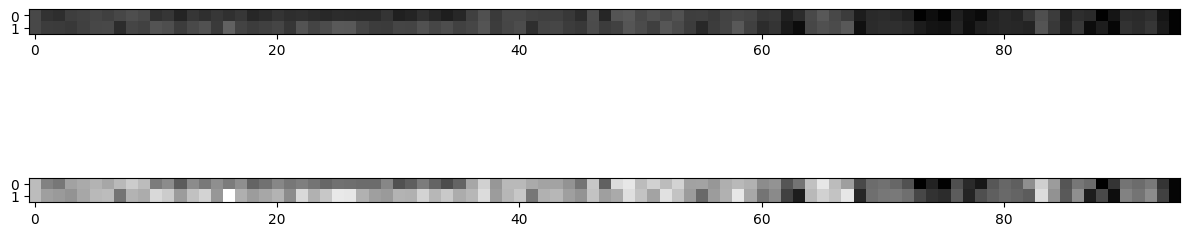

In [7]:
w_scale, h_scale = 1/letter_width, 2/height
resized_box = (int(img.width * w_scale), int(img.height * h_scale))
print(resized_box)
resized_img = img.resize(resized_box)
fig, axs = plt.subplots(nrows=2, figsize=(12, 8), layout='tight')
axs[0].imshow(resized_img, interpolation='nearest', cmap='gray', vmin=0, vmax=255)
axs[1].imshow(ImageOps.autocontrast(resized_img), interpolation='nearest', cmap='gray', vmin=0, vmax=255)

(285, 3)


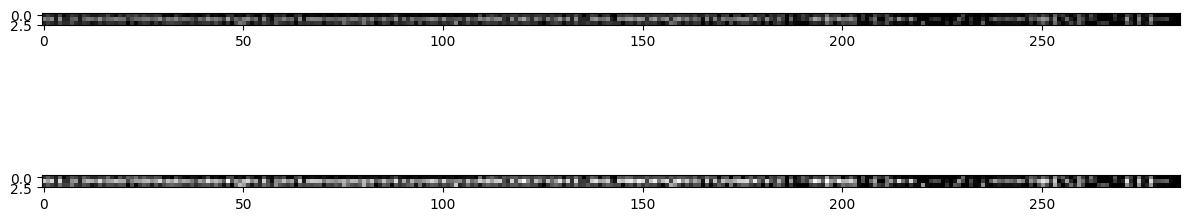

In [8]:
w_scale, h_scale = 3/letter_width, 3/height
resized_box = (int(img.width * w_scale), int(img.height * h_scale))
print(resized_box)
resized_img = img.resize(resized_box)
fig, axs = plt.subplots(nrows=2, figsize=(12, 8), layout='tight')
axs[0].imshow(resized_img, interpolation='nearest', cmap='gray', vmin=0, vmax=255)
axs[1].imshow(ImageOps.autocontrast(resized_img), interpolation='nearest', cmap='gray', vmin=0, vmax=255)

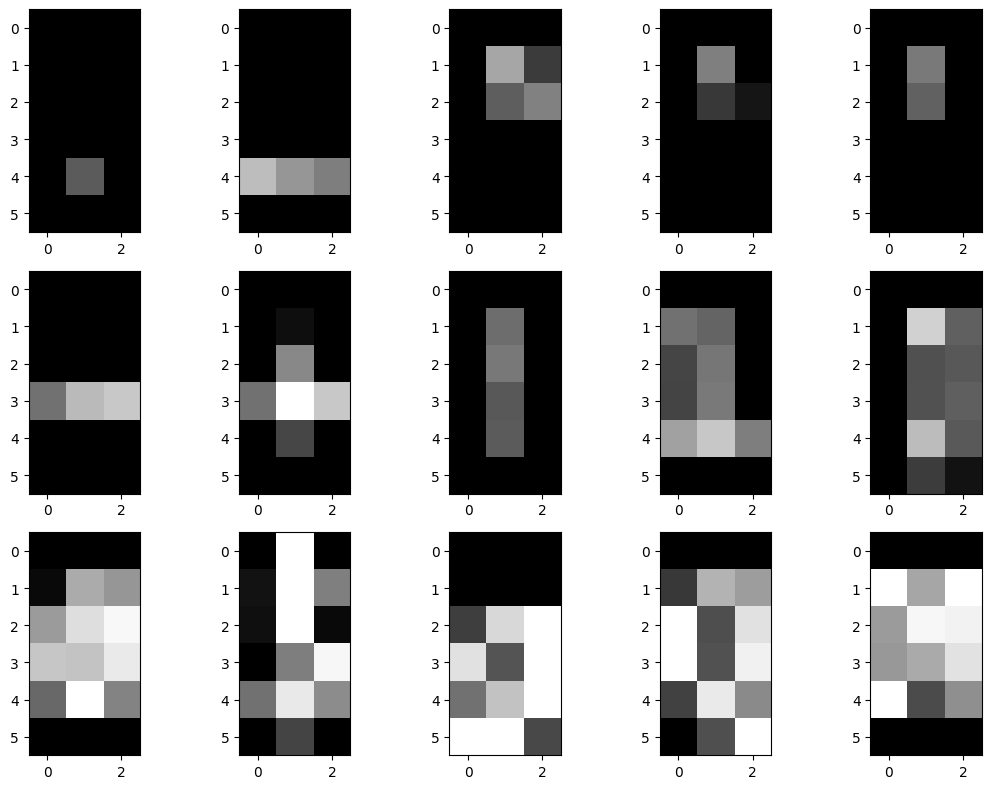

In [9]:
from modules.palette_generator import make_symbol2value_map

char_set = "._^`'-+!L]@$gQM"
brightness_map = make_symbol2value_map(char_set, fnt, val_width=3, val_height=6, normalize=True)
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(12, 8), layout='tight')
for i, b in enumerate(brightness_map.values()):
    axs[i//axs.shape[1]][i%axs.shape[1]].imshow(b, interpolation='nearest', cmap='gray', vmin=0, vmax=1)


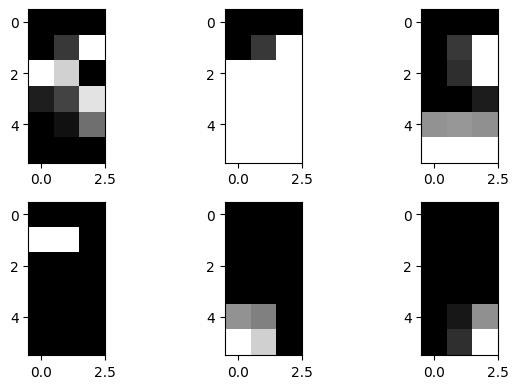

In [10]:
char_set = "⠪⣾⣘⠁⡀⢀"
brightness_map = make_symbol2value_map(char_set, fnt, val_width=3, val_height=6, normalize=True)
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(8, 4), layout='tight')
for i, b in enumerate(brightness_map.values()):
    axs[i//axs.shape[1]][i%axs.shape[1]].imshow(b, interpolation='nearest', cmap='gray', vmin=0, vmax=1)


19
dict_keys(['@', '/g', 'g/', '.g', 'g.', '/$', '$/', '.$', '$.', '__', '/_', '_/', '._', '_.', '//', '../', './.', '/..', '...'])


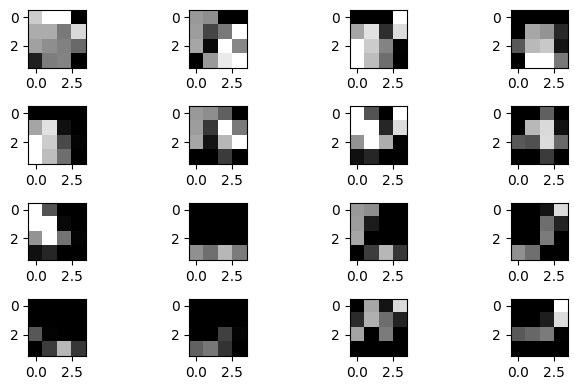

In [11]:
from modules.palette_generator import generate_non_mono_width_aligned_permutations

fnt_non_mono = ImageFont.truetype("../fonts/OpenSans-Regular.ttf", 11)
char_set = "._/$@g"
char_set = generate_non_mono_width_aligned_permutations(char_set, fnt_non_mono)
brightness_map = make_symbol2value_map(char_set, fnt_non_mono, val_width=4, val_height=4, normalize=True)
print(len(brightness_map))
print(brightness_map.keys())
nrows, ncols = 4, 4
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, 4), layout='tight')
for i, b in enumerate(brightness_map.values()):
    if i >= nrows * ncols:
        break
    axs[i//axs.shape[1]][i%axs.shape[1]].imshow(b, interpolation='nearest', cmap='gray', vmin=0, vmax=1)

In [12]:
unicode_blocks_start = 0x2580
unicode_blocks_end = 0x259F
unicode_blocks_palette = ""
for c in range(unicode_blocks_start, unicode_blocks_end+1):
    if (c % 16 == 0):
        print('\n', end='')
    print(chr(c), end=' ')
    unicode_blocks_palette += chr(c)


▀ ▁ ▂ ▃ ▄ ▅ ▆ ▇ █ ▉ ▊ ▋ ▌ ▍ ▎ ▏ 
▐ ░ ▒ ▓ ▔ ▕ ▖ ▗ ▘ ▙ ▚ ▛ ▜ ▝ ▞ ▟ 

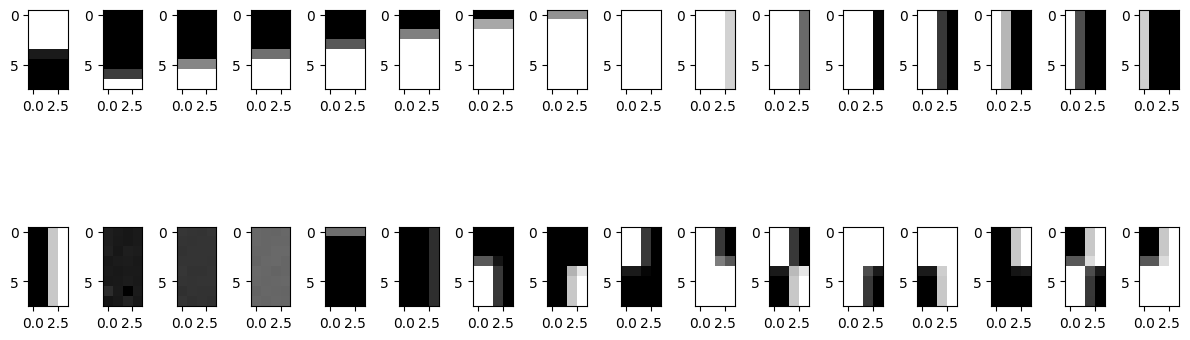

In [13]:
brightness_map = make_symbol2value_map(unicode_blocks_palette, fnt, val_width=4, val_height=8, normalize=True)
fig, axs = plt.subplots(nrows=2, ncols=16, figsize=(12, 8), layout='tight')
for i, b in enumerate(brightness_map.values()):
    axs[i//axs.shape[1]][i%axs.shape[1]].imshow(b, interpolation='nearest', cmap='gray', vmin=0, vmax=1)